In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

covid_df = pd.read_csv('covid.csv')
covid_grouped_df = pd.read_csv('covid_grouped.csv')
coviddeath_df = pd.read_csv('coviddeath.csv')

print("covid.csv info:")
print(covid_df.info())
print("\nNull sums in covid.csv:")
print(covid_df.isnull().sum())

print("\ncovid_grouped.csv info:")
print(covid_grouped_df.info())
print("\nNull sums in covid_grouped.csv:")
print(covid_grouped_df.isnull().sum())

print("\ncoviddeath.csv info:")
print(coviddeath_df.info())
print("\nNull sums in coviddeath.csv:")
print(coviddeath_df.isnull().sum())

covid.csv info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country/Region    209 non-null    object 
 1   Continent         208 non-null    object 
 2   Population        208 non-null    float64
 3   TotalCases        209 non-null    int64  
 4   NewCases          4 non-null      float64
 5   TotalDeaths       188 non-null    float64
 6   NewDeaths         3 non-null      float64
 7   TotalRecovered    205 non-null    float64
 8   NewRecovered      3 non-null      float64
 9   ActiveCases       205 non-null    float64
 10  Serious,Critical  122 non-null    float64
 11  Tot Cases/1M pop  208 non-null    float64
 12  Deaths/1M pop     187 non-null    float64
 13  TotalTests        191 non-null    float64
 14  Tests/1M pop      191 non-null    float64
 15  WHO Region        184 non-null    object 
 16  iso_alpha         209 non-nu

In [3]:
# Top 10 countries by TotalCases from covid.csv
top_cases = covid_df.sort_values('TotalCases', ascending=False).head(10)[['Country/Region', 'TotalCases', 'TotalDeaths', 'Continent']]
print("\nTop 10 countries by TotalCases:")
print(top_cases)

# Global time series sum from covid_grouped.csv
global_ts = covid_grouped_df.groupby('Date').sum(numeric_only=True)[['Confirmed', 'Deaths', 'New cases', 'New deaths']]
print("\nGlobal time series head and tail:")
print(global_ts.head())
print(global_ts.tail())

# Deaths by condition from coviddeath.csv
death_by_condition = coviddeath_df.groupby('Condition Group')['Number of COVID-19 Deaths'].sum().sort_values(ascending=False)
print("\nUS Deaths by Condition Group:")
print(death_by_condition)

# Deaths by age
death_by_age = coviddeath_df.groupby('Age Group')['Number of COVID-19 Deaths'].sum().sort_values(ascending=False)
print("\nUS Deaths by Age Group:")
print(death_by_age)

# Correlation in covid.csv (numerical)
num_cols = covid_df.select_dtypes(include=np.number).columns
corr = covid_df[num_cols].corr()
print("\nCorrelation matrix (top correlations):")
print(corr['TotalCases'].sort_values(ascending=False).head(10))


Top 10 countries by TotalCases:
  Country/Region  TotalCases  TotalDeaths      Continent
0            USA     5032179     162804.0  North America
1         Brazil     2917562      98644.0  South America
2          India     2025409      41638.0           Asia
3         Russia      871894      14606.0         Europe
4   South Africa      538184       9604.0         Africa
5         Mexico      462690      50517.0  North America
6           Peru      455409      20424.0  South America
7          Chile      366671       9889.0  South America
8       Colombia      357710      11939.0  South America
9          Spain      354530      28500.0         Europe

Global time series head and tail:
            Confirmed  Deaths  New cases  New deaths
Date                                                
2020-01-22        555      17          0           0
2020-01-23        654      18         99           1
2020-01-24        941      26        287           8
2020-01-25       1434      42        493

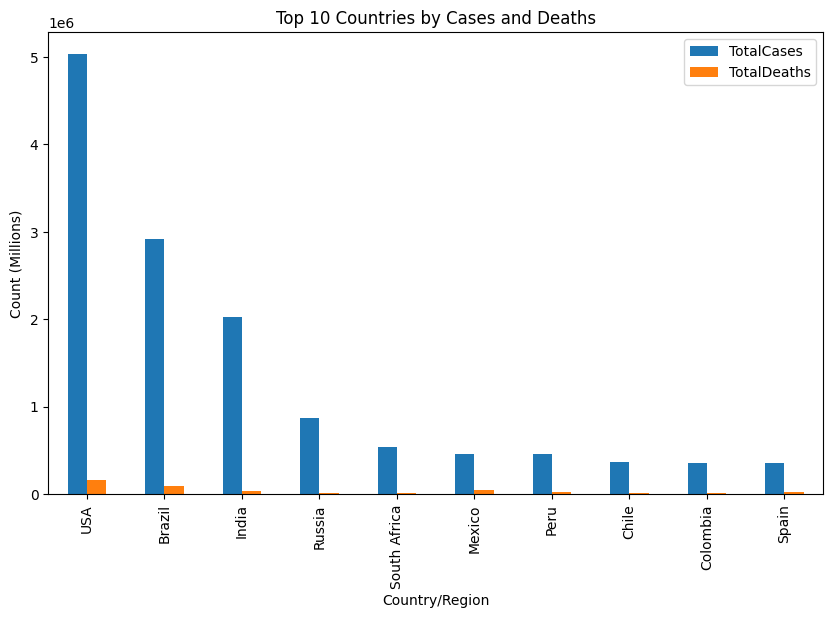

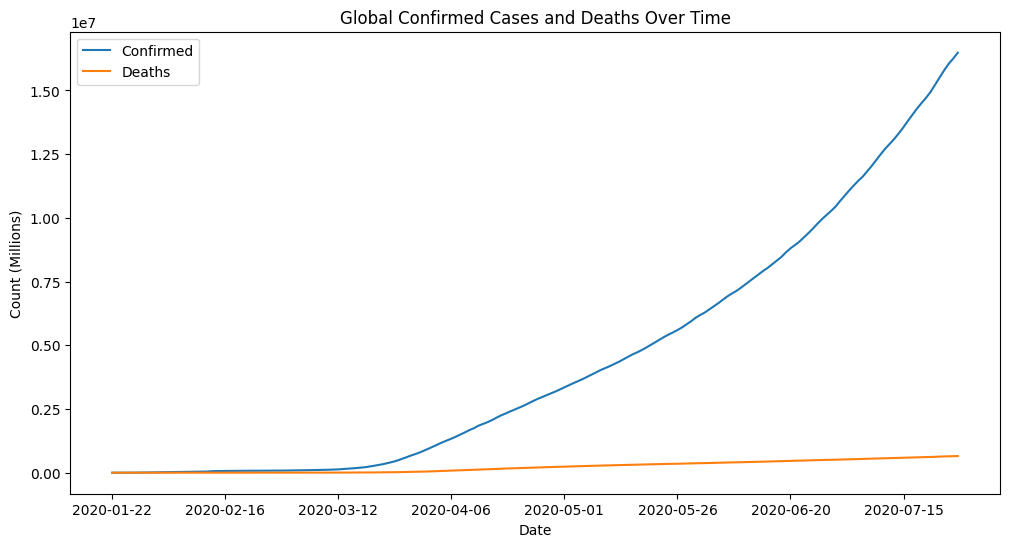

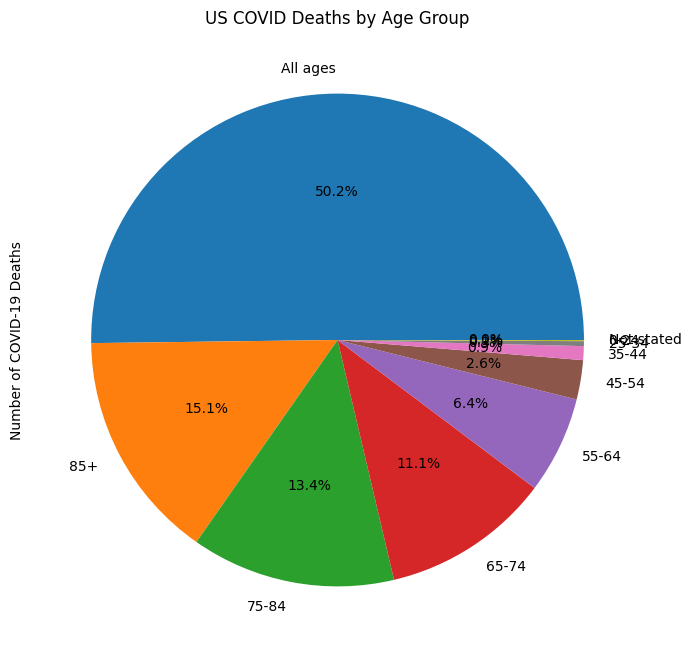

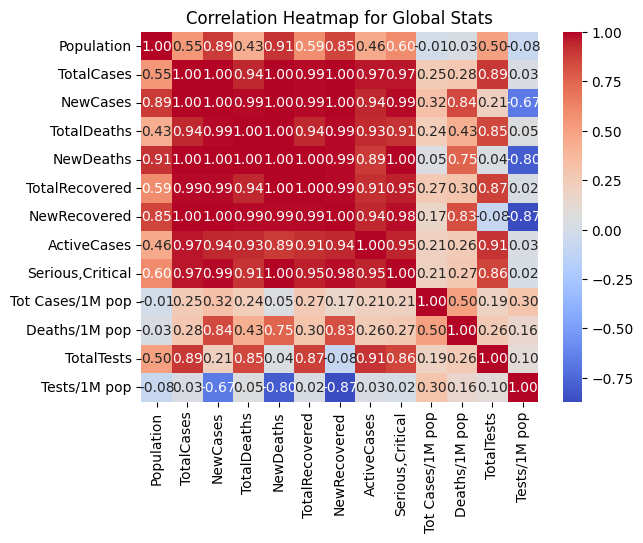

In [4]:
# Plot 1: Top 10 Countries Bar Chart (from covid.csv)
top_cases.plot(x='Country/Region', y=['TotalCases', 'TotalDeaths'], kind='bar', figsize=(10,6))
plt.title('Top 10 Countries by Cases and Deaths')
plt.ylabel('Count (Millions)')
plt.show()  # In Jupyter, this displays the bar chart

# Plot 2: Global Time-Series Line Plot (from covid_grouped.csv)
global_ts[['Confirmed', 'Deaths']].plot(figsize=(12,6))
plt.title('Global Confirmed Cases and Deaths Over Time')
plt.ylabel('Count (Millions)')
plt.show()

# Plot 3: US Deaths by Age Pie Chart (from coviddeath.csv)
death_by_age.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
plt.title('US COVID Deaths by Age Group')
plt.show()

# Plot 4: Correlation Heatmap (from covid.csv)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Global Stats')
plt.show()

In [5]:
plt.savefig('plot1.png')

<Figure size 640x480 with 0 Axes>